# Hoja de Trabajo 2 - Deep Learning y sistemas inteligentes

### Sebastian Juárez - 21471

## Ejercicio 1 - Experimentación Practica

## Preparacion de los datos

In [2]:
import time, math, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

def one_hot(y, num_classes):
    oh = np.zeros((y.shape[0], num_classes), dtype=np.float32)
    oh[np.arange(y.shape[0]), y] = 1.0
    return oh

def l1_penalty(model):
    return sum(p.abs().sum() for p in model.parameters() if p.requires_grad)

def plot_curves(hist, title_prefix=""):
    epochs = range(1, len(hist['train_loss'])+1)
    plt.figure();
    plt.plot(epochs, hist['train_loss'], label='train_loss');
    plt.plot(epochs, hist['val_loss'], label='val_loss');
    plt.xlabel('Época'); plt.ylabel('Pérdida'); plt.title(f'{title_prefix} - Loss'); plt.legend(); plt.show()

    plt.figure();
    plt.plot(epochs, hist['train_acc'], label='train_acc');
    plt.plot(epochs, hist['val_acc'], label='val_acc');
    plt.xlabel('Época'); plt.ylabel('Accuracy'); plt.title(f'{title_prefix} - Accuracy'); plt.legend(); plt.show()

    plt.figure();
    plt.plot(epochs, hist['train_f1'], label='train_f1');
    plt.plot(epochs, hist['val_f1'], label='val_f1');
    plt.xlabel('Época'); plt.ylabel('F1 macro'); plt.title(f'{title_prefix} - F1'); plt.legend(); plt.show()


Device: cuda


## Task 1: Obtención de los datos

In [3]:
iris = load_iris()
X = iris['data'].astype(np.float32)
y = iris['target'].astype(np.int64)
num_classes = len(np.unique(y))

scaler = StandardScaler()
X = scaler.fit_transform(X).astype(np.float32)

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_val_t   = torch.from_numpy(X_val)
y_val_t   = torch.from_numpy(y_val)

def make_loaders(batch_mode="mini", batch_size=16):
    if batch_mode == "batch":
        bs = len(X_train_t)
    elif batch_mode == "sgd":
        bs = 1
    else:
        bs = batch_size

    train_ds = TensorDataset(X_train_t, y_train_t)
    val_ds   = TensorDataset(X_val_t, y_val_t)
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=len(val_ds), shuffle=False)
    return train_loader, val_loader

print("Train size:", len(X_train_t), "Val size:", len(X_val_t))


Train size: 112 Val size: 38


## Task 2: Arquitectura del modelo

In [4]:
class FFN(nn.Module):
    def __init__(self, in_dim, hidden_dims=(32, 16), out_dim=3, dropout_p=0.0):
        super().__init__()
        layers = []
        last = in_dim
        for h in hidden_dims:
            layers += [nn.Linear(last, h), nn.ReLU()]
            if dropout_p > 0:
                layers += [nn.Dropout(dropout_p)]
            last = h
        layers += [nn.Linear(last, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


## Tasks 3/4/5: Perdida, Regularización y algoritmos

In [5]:
def get_loss_fn(name, num_classes):
    name = name.lower()
    if name in ["ce", "cross_entropy", "cross-entropy"]:
        return "ce", nn.CrossEntropyLoss()
    elif name in ["mse"]:
        return "mse", nn.MSELoss()
    elif name in ["nll", "negative_log_likelihood"]:
        return "nll", nn.NLLLoss()
    else:
        raise ValueError(f"Pérdida no soportada: {name}")

# Trainer con diferentes opciones
def train_run(
    loss_name="cross_entropy",
    reg_type="none",
    l1_lambda=0.0,
    l2_weight_decay=0.0,
    dropout_p=0.0,
    batch_mode="mini",
    batch_size=16,
    hidden_dims=(32,16),
    lr=0.05,
    epochs=60,
    verbose=False
):
    train_loader, val_loader = make_loaders(batch_mode, batch_size)

    model = FFN(in_dim=X_train.shape[1], hidden_dims=hidden_dims, out_dim=num_classes, dropout_p=dropout_p).to(DEVICE)
    loss_tag, loss_fn = get_loss_fn(loss_name, num_classes)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=(l2_weight_decay if reg_type=="l2" else 0.0))

    hist = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","train_f1","val_f1"]}
    t0 = time.perf_counter()

    for ep in range(1, epochs+1):
        # Train
        model.train()
        batch_losses, y_true_train, y_pred_train = [], [], []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)

            if loss_tag == "ce":
                loss = loss_fn(logits, yb)
                probs = torch.softmax(logits, dim=1)
            elif loss_tag == "mse":
                probs = torch.softmax(logits, dim=1)
                y_onehot = torch.from_numpy(one_hot(yb.cpu().numpy(), num_classes)).to(DEVICE)
                loss = loss_fn(probs, y_onehot)
            else:
                log_probs = torch.log_softmax(logits, dim=1)
                loss = loss_fn(log_probs, yb)
                probs = torch.softmax(logits, dim=1)

            if reg_type == "l1" and l1_lambda > 0:
                loss = loss + l1_lambda * l1_penalty(model)

            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())
            y_true_train.extend(yb.detach().cpu().numpy().tolist())
            y_pred_train.extend(probs.argmax(dim=1).detach().cpu().numpy().tolist())

        train_loss = float(np.mean(batch_losses))
        train_acc = accuracy_score(y_true_train, y_pred_train)
        train_f1  = f1_score(y_true_train, y_pred_train, average="macro")

        # Evaluación
        model.eval()
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                if loss_tag == "ce":
                    val_loss = loss_fn(logits, yb).item()
                    probs = torch.softmax(logits, dim=1)
                elif loss_tag == "mse":
                    probs = torch.softmax(logits, dim=1)
                    y_onehot = torch.from_numpy(one_hot(yb.cpu().numpy(), num_classes)).to(DEVICE)
                    val_loss = loss_fn(probs, y_onehot).item()
                else:
                    log_probs = torch.log_softmax(logits, dim=1)
                    val_loss = loss_fn(log_probs, yb).item()
                    probs = torch.softmax(logits, dim=1)

                y_pred_val = probs.argmax(dim=1).detach().cpu().numpy()
                y_true_val = yb.detach().cpu().numpy()

        val_acc = accuracy_score(y_true_val, y_pred_val)
        val_f1  = f1_score(y_true_val, y_pred_val, average="macro")

        hist['train_loss'].append(train_loss); hist['val_loss'].append(val_loss)
        hist['train_acc' ].append(train_acc ); hist['val_acc' ].append(val_acc )
        hist['train_f1'  ].append(train_f1  ); hist['val_f1'  ].append(val_f1  )

        if verbose and ep % 10 == 0:
            print(f"Ep {ep:03d} | loss {train_loss:.4f}/{val_loss:.4f} | acc {train_acc:.3f}/{val_acc:.3f} | f1 {train_f1:.3f}/{val_f1:.3f}")

    t1 = time.perf_counter()
    dur_s = t1 - t0

    cm = confusion_matrix(y_true_val, y_pred_val)

    result = {
        "hist": hist,
        "cm_val": cm,
        "best_val_acc": max(hist['val_acc']),
        "best_val_f1": max(hist['val_f1']),
        "final_val_loss": hist['val_loss'][-1],
        "time_sec": dur_s,
        "config": {
            "loss": loss_name,
            "reg_type": reg_type,
            "dropout_p": dropout_p,
            "l1_lambda": l1_lambda,
            "l2_weight_decay": l2_weight_decay,
            "batch_mode": batch_mode,
            "batch_size": batch_size,
            "hidden_dims": hidden_dims,
            "lr": lr,
            "epochs": epochs
        }
    }
    return result


## Task 6: Experimentación y analisis

In [6]:
losses = ["cross_entropy", "mse", "nll"]
regs   = ["none", "l2", "dropout"]

results = []
for loss_name in losses:
    for reg in regs:
        cfg = dict(
            loss_name=loss_name,
            reg_type=reg,
            l1_lambda=0.0,
            l2_weight_decay=(1e-3 if reg=="l2" else 0.0),
            dropout_p=(0.30 if reg=="dropout" else 0.0),
            batch_mode="mini",
            batch_size=16,
            hidden_dims=(32,16),
            lr=0.05,
            epochs=80,
            verbose=False
        )
        res = train_run(**cfg)
        results.append(res)

summary = []
for r in results:
    c = r["config"]
    summary.append({
        "loss": c["loss"],
        "reg": c["reg_type"],
        "dropout": c["dropout_p"],
        "l2_wd": c["l2_weight_decay"],
        "best_val_acc": r["best_val_acc"],
        "best_val_f1": r["best_val_f1"],
        "final_val_loss": r["final_val_loss"],
        "time_sec": r["time_sec"]
    })

import pandas as pd
df_summary = pd.DataFrame(summary).sort_values(["best_val_acc","best_val_f1"], ascending=False).reset_index(drop=True)
df_summary


,loss,reg,dropout,l2_wd,best_val_acc,best_val_f1,final_val_loss,time_sec
0,cross_entropy,none,0.0,0.000,0.973684,0.974321,0.090951,1.737693
1,cross_entropy,l2,0.0,0.001,0.973684,0.974321,0.121284,1.375043
2,cross_entropy,dropout,0.3,0.000,0.973684,0.974321,0.135665,1.432494
3,nll,none,0.0,0.000,0.973684,0.974321,0.120980,1.321051
4,nll,dropout,0.3,0.000,0.973684,0.974321,0.136804,1.395238
5,nll,l2,0.0,0.001,0.947368,0.948718,0.114607,1.324015
6,mse,none,0.0,0.000,0.894737,0.897436,0.068242,1.583998
7,mse,l2,0.0,0.001,0.868421,0.870065,0.073927,1.812978
8,mse,dropout,0.3,0.000,0.868421,0.870065,0.070308,1.664695


Tomamos los mejores datos del las pruebas para poder graficarlas y entender el aprendizaje del modelo

Mejor config: {'loss': 'cross_entropy', 'reg': 'none', 'dropout': 0.0, 'l2_wd': 0.0}


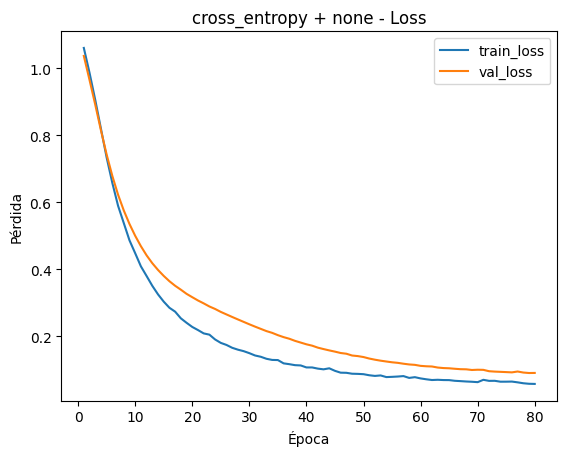

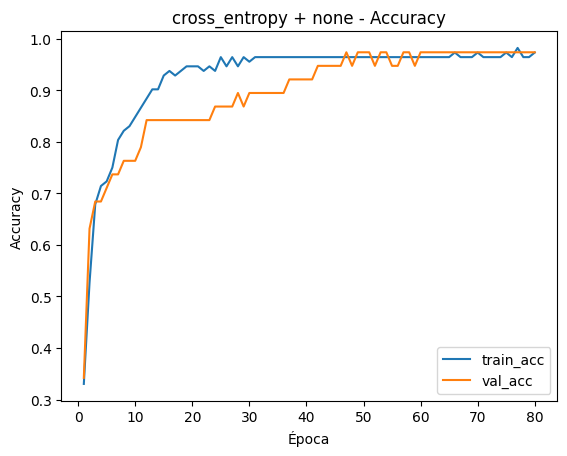

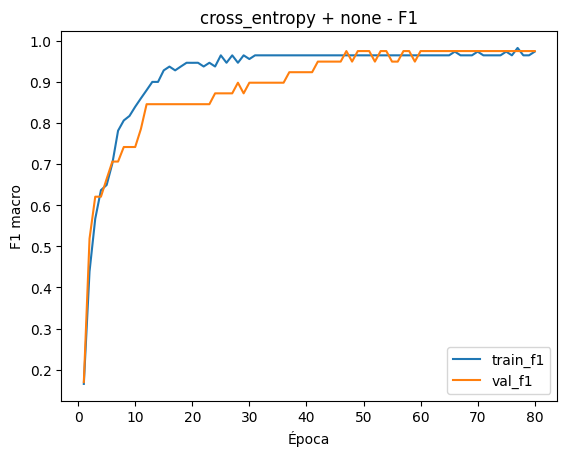

Matriz de confusión (validación):
[[12  0  0]
 [ 0 12  1]
 [ 0  0 13]]


In [7]:
best_idx = df_summary.index[0]
best_conf = df_summary.loc[best_idx, ["loss","reg","dropout","l2_wd"]].to_dict()
print("Mejor config:", best_conf)

def match_result(row):
    for r in results:
        c = r["config"]
        if (c["loss"] == row["loss"]) and (c["reg_type"] == row["reg"]) \
           and (abs(c["dropout_p"] - row["dropout"]) < 1e-8) \
           and (abs(c["l2_weight_decay"] - row["l2_wd"]) < 1e-12):
            return r
    return None

best_run = match_result(df_summary.loc[best_idx])
plot_curves(best_run["hist"], title_prefix=f"{best_conf['loss']} + {best_conf['reg']}")

print("Matriz de confusión (validación):")
print(best_run["cm_val"])


In [8]:
modes = [("batch", None), ("mini", 16), ("sgd", None)]
algo_summary = []
for mode, bs in modes:
    res = train_run(
        loss_name="cross_entropy",
        reg_type="none",
        dropout_p=0.0,
        l2_weight_decay=0.0,
        batch_mode=mode,
        batch_size=(bs if bs is not None else 16),
        lr=0.05, epochs=80, verbose=False
    )
    algo_summary.append({
        "mode": mode,
        "best_val_acc": res["best_val_acc"],
        "best_val_f1": res["best_val_f1"],
        "time_sec": res["time_sec"]
    })
pd.DataFrame(algo_summary)


,mode,best_val_acc,best_val_f1,time_sec
0,batch,0.842105,0.842424,0.605368
1,mini,0.973684,0.974321,1.290985
2,sgd,0.973684,0.974321,13.670004


## Resultados

Probamos 3 funciones de pérdida (Cross-Entropy, NLL y MSE) y las trabajamos con 3 funciones de regularización (ninguno, L2 y Dropout). La mejor configuración fue Cross-Entropy sin regularización, con val_acc = 0.9737 y val_f1 = 0.9743. NLL obtuvo métricas bastante parecidas, lo que se puede llegar a esperar porque CE es casi lo mismo que aplicar log-softmax seguido de NLL.

Por otro lado, MSE rindió peor (val_acc ≈ 0.895), y esto se puede atribuir a que esta no es la perdida que se usa normalmente para clasificación multiclase. O sea que optimiza distancias cuadráticas, no la probabilidad logarítmica que es lo que esperariamos.


En regularización, L2 y Dropout (0.3) no mejoraron el rendimiento. Sabemos que Iris es un conjunto bastante pequeño y bien separado, introducir L2 o Dropout termina reduciendo todavia más este numero sin que hayan beneficios.


Al comparar algoritmos o tamaños de batch, mini-batch alcanzó el resultado entre calidad y tiempo, misma val_acc que SGD, pero muchisimo más rápido. Full-batch fue el más rápido por época, pero generalizó peor (val_acc ≈ 0.842).
Las curvas de  las graficas muestran lineas estables, por lo que podemos pensar sobreajuste es mínimo.

## Ejercicio 2 - Repaso de teoria

**1. ¿Cuál es la principal innovación de la arquitectura Transformer?**  

El nuevo Transformer quita las partes que leen paso a paso y trabaja solo con “atención”. Eso nos deja entrenar en paralelo y ver las relaciones entre las palabras mas facilmente.

**2. ¿Cómo funciona el mecanismo de atención del scaled dot-product?**

Para cada palabra, el modelo ve todas las demás y decide a cuáles ponerles más atención. Despues el sistema combina la información segun lo que encuentre importante.

**3. ¿Por qué se utiliza la atención de múltiples cabezales en Transformer?**  

Por que cada cabezal se puede enfocar en diferentes cosas al mismo tiempo. Mezclando esto, el modelo entiende mejor la oracion con con una sola por vez.

**4. ¿Cómo se incorporan los positional encodings en el modelo Transformer?**

El transformer no sabe cual es el orden él mismo, por esto se le ponen etiquetas de posicion a cada palabra para que el modelo distinga cual es el ordern que tiene que seguir.

**5. ¿Cuáles son algunas aplicaciones de la arquitectura Transformer más allá de la machine translation?**  

En este articulo, se prueba esto mas que nada en traducción. Ademas muestran como esto funciona bien en el analisis sintactico en ingles. Lo que buscan es dar la idea general para las tareas de entrada y salida secuenciales, no solamente para la traducción.
